# Assignment 2

In [1]:
import pandas as pd

# Specify the path to your CSV file
csv_path = "query_product.csv"

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(csv_path, encoding="latin1")
desc = pd.read_csv('product_descriptions.csv', encoding='latin1')
df = df.merge(desc, on='product_uid', how='left')

In [2]:
df['relevance'].describe()

count    74067.000000
mean         2.381634
std          0.533984
min          1.000000
25%          2.000000
50%          2.330000
75%          3.000000
max          3.000000
Name: relevance, dtype: float64

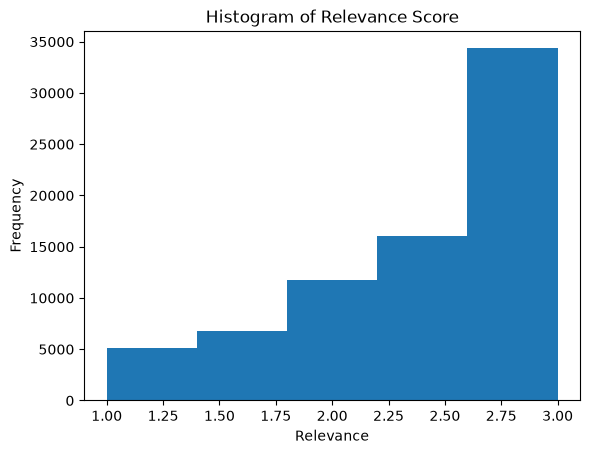

In [3]:
import matplotlib.pyplot as plt

# Assuming you have a DataFrame named data_frame
# and you want to visualize a column named 'column_name'

# Create a histogram of the column's values
plt.hist(df['relevance'], bins=5)

# Add labels and title
plt.xlabel('Relevance')
plt.ylabel('Frequency')
plt.title('Histogram of Relevance Score')

# Display the plot
plt.show()

In [4]:
from gensim.models import Word2Vec

# Tokenize all descriptions
desc_tokens = df['product_description'].apply(
    lambda x: str(x).lower().split()
).tolist()

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=desc_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)

print(f"Vocabulary size: {len(w2v_model.wv)}")

Vocabulary size: 151541


In [5]:
from sklearn.model_selection import train_test_split


# Set the training size
training_size = 50000

# Split the DataFrame into training and test sets
train_data, test_data = train_test_split(df, test_size=(len(df) - training_size), random_state=42)

# Display the training data
train_data

# Display the test data
test_data

,id,product_uid,product_title,search_term,relevance,product_description
13534,41864,110074,DEWALT 20-Volt Max Lithium-Ion Cordless Combo ...,commercial cordless drill set,3.00,The DEWALT DCKTS240C2 Combo kit is versatile e...
29748,91116,127729,Cerrowire 15 Amp 125-Volt Stay Plugged Replace...,15 Amp Extension Cord,2.67,This black and yellow Stay Plug Cord replaceme...
20225,62389,116912,Broan Allure 2 Series 30 in. Convertible Range...,30 inch under cabinet stainless range hood,2.67,The BroanAllureII line of range hoods feature ...
5169,16212,102866,Gardner Bender 1/2 in. Black Polyolefin Heat S...,heat shrink tubing,2.67,The 1/2 in. Black Polyolefin Heat Shrink Tubin...
49860,151456,156894,Stainless Glide Stainless Steel Strap Rolling ...,stainless steel hardware,2.00,The Stainless Glide Stainless Steel Rolling Do...
...,...,...,...,...,...,...
16502,50892,113039,Roberts 360 sq. ft. Felt Cushion Underlayment ...,underlayment for laminate flooring,3.00,The Roberts 70-193 super felt premium underlay...
54982,166615,165859,Steves &amp; Sons 36 in. x 80 in. Premium 1-Pa...,steves and sons 6panel white,2.33,The Steves and Sons Premium 1-Panel with high-...
60036,181204,175353,Sterilite 12 Gal. Latch and Carry Tote (6-Pack),carrrs,2.00,The 12 Gal. Latch and Carry Clear is great for...
22047,68083,118908,iTouchless Bio-Matic Fingerprint Gold Right Ha...,fingerprint lock,3.00,Save your family the need to carry bulky key c...


In [6]:
import numpy as np

def sentence_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

def cosine_sim(vec1, vec2):
    if np.linalg.norm(vec1) == 0 or np.linalg.norm(vec2) == 0:
        return 0
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))


train_data['query_words'] = train_data['search_term'].apply(lambda x: set(x.lower().split()))
train_data['title_words'] = train_data['product_title'].apply(lambda x: set(x.lower().split()))
test_data['query_words']  = test_data['search_term'].apply(lambda x: set(x.lower().split()))
test_data['title_words']  = test_data['product_title'].apply(lambda x: set(x.lower().split()))

def check_words(row):
    return int(row['query_words'].issubset(row['title_words']))

def frac_words_in_title(row):
    if not row['query_words']: return 0
    return len(row['query_words'] & row['title_words']) / len(row['query_words'])

def query_length(row):
    return len (row['search_term'].lower().split())

def frac_words_in_desc(row):
    words_desc = set(str(row['product_description']).lower().split())
    if not row['query_words']: return 0
    return len(row['query_words'] & words_desc) / len(row['query_words'])

def title_length(row):
    return len(row['title_words'])

def n_words_in_title(row):
    return len(row['query_words'] & row['title_words'])

def exact_match(row):
    query = row['search_term'].lower()
    title = row['product_title'].lower()
    return int(query in title)

def desc_length(row):
    return len(str(row['product_description']).lower().split())

def cosine_sim_title(row):
    q_vec = sentence_vector(row['search_term'].lower().split(), w2v_model)
    t_vec = sentence_vector(row['product_title'].lower().split(), w2v_model)
    return cosine_sim(q_vec, t_vec)

def cosine_sim_desc(row):
    q_vec = sentence_vector(row['search_term'].lower().split(), w2v_model)
    d_vec = sentence_vector(str(row['product_description']).lower().split(), w2v_model)
    return cosine_sim(q_vec, d_vec)


train_data['all_words_in_title'] = train_data.apply(check_words, axis=1)
train_data['frac_words_in_title'] = train_data.apply(frac_words_in_title, axis=1)
train_data['query_length'] = train_data.apply(query_length, axis=1)
train_data['frac_words_in_desc'] = train_data.apply(frac_words_in_desc, axis=1)
train_data['title_length'] = train_data.apply(title_length, axis=1)
train_data['n_words_in_title'] = train_data.apply(n_words_in_title, axis=1)
train_data['exact_match'] = train_data.apply(exact_match, axis=1)
train_data['desc_length'] = train_data.apply(desc_length, axis=1)
train_data['cosine_sim_title'] = train_data.apply(cosine_sim_title, axis=1)
train_data['cosine_sim_desc']  = train_data.apply(cosine_sim_desc, axis=1)

test_data['all_words_in_title'] = test_data.apply(check_words, axis=1)
test_data['frac_words_in_title'] = test_data.apply(frac_words_in_title, axis=1)
test_data['query_length'] = test_data.apply(query_length, axis=1)
test_data['frac_words_in_desc']  = test_data.apply(frac_words_in_desc, axis=1)
test_data['title_length'] = test_data.apply(title_length, axis=1)
test_data['n_words_in_title'] = test_data.apply(n_words_in_title, axis=1)
test_data['exact_match'] = test_data.apply(exact_match, axis=1)
test_data['desc_length'] = test_data.apply(exact_match, axis=1)
test_data['cosine_sim_title']  = test_data.apply(cosine_sim_title, axis=1)
test_data['cosine_sim_desc']   = test_data.apply(cosine_sim_desc, axis=1)

train_data

,id,product_uid,product_title,search_term,relevance,product_description,query_words,title_words,all_words_in_title,frac_words_in_title,query_length,frac_words_in_desc,title_length,n_words_in_title,exact_match,desc_length,cosine_sim_title,cosine_sim_desc
24891,76418,121965,LG Electronics 26.16 cu. ft. Side by Side Refr...,hickory refrigerator side,2.33,"With a generous 26.16 cu. ft., this Side-By-Si...","{refrigerator, side, hickory}","{by, side, cu., in, ft., 26.16, refrigerator, ...",0,0.666667,3,0.333333,11,2,0,367,0.681040,0.605985
57342,173365,170104,MPG 20-1/2 in. H Cast Stone Cherub with Flute ...,granite counter special offers,1.00,This exclusive cherub with flute will give a s...,"{counter, granite, offers, special}","{in., h, cherub, flute, in, 20-1/2, stone, wit...",0,0.500000,4,0.000000,14,2,0,73,0.527588,0.380212
8779,27292,105664,Patio Living Concepts Catalina Bisque Umbrella...,small outdoor tables,1.67,"Carefree resin durability, while adding elegan...","{small, tables, outdoor}","{concepts, lamp, table, patio, with, shade, bi...",0,0.666667,3,0.333333,14,2,0,162,0.773318,0.362559
13929,43039,110439,TruAire 10 in. x 6 in. 2-Way Wall/Ceiling Regi...,air vent cover,2.33,The H102M 10X06 is 10 in. x 6 in. 2-way air re...,"{vent, air, cover}","{10, in., x, wall/ceiling, truaire, 6, registe...",0,0.000000,3,0.333333,8,0,0,87,0.260208,0.566887
48541,147368,154589,Stair Parts 4000 3 in. x 66 in. Unfinished Red...,stair newel post,2.33,The stair part that anchors the stair railing ...,"{newel, post, stair}","{66, in., unfinished, oak, newel, x, red, post...",1,1.000000,3,0.666667,12,3,0,126,0.657155,0.495982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,113741,137561,Prime-Line 1/4 in. x 8 ft. Stainless Steel Sli...,pocket screens for garage,1.33,This patio door track cover is constructed fro...,"{for, pocket, garage, screens}","{track, in., 1/4, prime-line, x, ft., repair, ...",0,0.000000,4,0.250000,12,0,0,65,0.391193,0.612827
6265,19679,103542,Aquatic Composite 30 in. x 60 in. x 6 in. Sing...,aquatic shower base,3.00,Composite shower bases feature a patented syst...,"{base, aquatic, shower}","{base, in., in, 30, x, aquatic, shower, biscui...",1,1.000000,3,0.333333,15,3,0,76,0.540833,0.326128
54886,166345,165690,Pleasant Hearth Alpine Medium Glass Fireplace ...,glass and chrome fireplace screen,2.67,"Designed for a traditional masonry fireplace, ...","{glass, screen, and, chrome, fireplace}","{alpine, glass, hearth, doors, medium, firepla...",0,0.400000,5,0.600000,7,2,0,231,0.754893,0.716794
860,2735,100478,Fiskars 14 ft. Bypass Pruner,pole saws,1.67,Make reaching and cutting high branches easier...,"{pole, saws}","{fiskars, ft., bypass, pruner, 14}",0,0.000000,2,0.500000,5,0,0,164,0.374730,0.548561


In [7]:
train_data[train_data['all_words_in_title'] == True]

,id,product_uid,product_title,search_term,relevance,product_description,query_words,title_words,all_words_in_title,frac_words_in_title,query_length,frac_words_in_desc,title_length,n_words_in_title,exact_match,desc_length,cosine_sim_title,cosine_sim_desc
48541,147368,154589,Stair Parts 4000 3 in. x 66 in. Unfinished Red...,stair newel post,2.33,The stair part that anchors the stair railing ...,"{newel, post, stair}","{66, in., unfinished, oak, newel, x, red, post...",1,1.0,3,0.666667,12,3,0,126,0.657155,0.495982
52453,159323,161440,Everbilt 3-1/2 in. Chrome 5/8 in. Radius Secur...,chrome door hinges,3.00,The Everbilt 3-1/2 in. 5/8 in. Radius Door Hin...,"{door, chrome, hinges}","{in., 5/8, hinges, (3-pack), everbilt, 3-1/2, ...",1,1.0,3,0.666667,10,3,0,54,0.756790,0.485800
13301,41144,109867,Spectrum Via Vinyl Accordion Door,accordion door,2.33,The Spectrum Via 36 in. x 80 in. Vinyl White A...,"{door, accordion}","{via, accordion, vinyl, spectrum, door}",1,1.0,2,1.000000,5,2,1,125,0.789064,0.546314
35679,109102,135437,RIDGID 12 in. Sliding Compound Miter Saw with ...,12 compound miter saw,2.67,The RIDGID 12 in. Sliding Compound Miter Saw w...,"{12, compound, saw, miter}","{ridgid, compound, in., saw, miter, with, free...",1,1.0,4,1.000000,11,4,0,259,0.877170,0.564522
34761,106300,134191,"All Power 3,500-Watt Propane Portable Generator",portable propane generator,2.33,The propane powered APG3535CN is more efficien...,"{generator, propane, portable}","{all, 3,500-watt, generator, power, propane, p...",1,1.0,3,0.333333,6,3,0,114,0.827129,0.495294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10627,32812,107326,Aston Aquadica 38 in. x 72 in. Frameless Squar...,glass shower enclosure,3.00,"Give your bathroom a refreshed, modern look wi...","{glass, shower, enclosure}","{aston, in., glass, enclosure, in, 72, x, with...",1,1.0,3,0.666667,16,3,0,144,0.675071,0.546864
3890,12091,102117,Ameriwood 2-Drawer File Cabinet in Black Ebony...,file cabinet,3.00,Keep your files organized and stored away in t...,"{cabinet, file}","{2-drawer, in, ameriwood, cabinet, ash, file, ...",1,1.0,2,1.000000,8,2,1,139,0.752577,0.485493
25658,78783,122858,Premier 24 in. 2.97 cu. ft. Freestanding Elect...,24 in electric range,1.67,24 in. Electric Range in White2.97 cu. ft. fu...,"{in, range, electric, 24}","{cu., in., range, 2.97, premier, electric, in,...",1,1.0,4,1.000000,11,4,0,148,0.780635,0.540458
41090,125258,143060,Liberty 10 in. x 10 in. Vintage Inspired Clear...,chevron,1.67,Transform your space with these decorative fur...,{chevron},"{liberty, 10, in., furniture, x, chevron, sten...",1,1.0,1,0.000000,10,1,1,72,0.234214,-0.024094


In [8]:
train_data['all_words_in_title'].describe()

count    50000.000000
mean         0.175980
std          0.380807
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: all_words_in_title, dtype: float64

In [28]:
import statsmodels.api as sm

# Define the feature and target variables
feature_cols = ['all_words_in_title', 'frac_words_in_title', 'query_length', 'frac_words_in_desc', 'title_length', 'n_words_in_title', 'exact_match', 'desc_length', 'cosine_sim_title', 'cosine_sim_desc']
X = sm.add_constant(train_data[feature_cols])
y = train_data['relevance']

# Add a constant term to the feature variable
X = sm.add_constant(X)

# Create a linear regression model
model = sm.OLS(y, X)

# Fit the model to the data
results = model.fit()

# Print the model summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              relevance   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     684.0
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        00:14:46   Log-Likelihood:                -36375.
No. Observations:               50000   AIC:                         7.277e+04
Df Residuals:                   49989   BIC:                         7.287e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.2452    

In [29]:
# Filter to exact scores only
df_class = df[df['relevance'].isin([1.0, 2.0, 3.0])].copy()
print(df_class['relevance'].value_counts())

relevance
3.0    19125
2.0    11730
1.0     2105
Name: count, dtype: int64


In [30]:
from sklearn.model_selection import train_test_split

train_class, test_class = train_test_split(df_class, test_size=0.33, random_state=42)

print(f'Train size: {len(train_class)}')
print(f'Test size:  {len(test_class)}')

Train size: 22083
Test size:  10877


In [ ]:
train_class['query_words'] = train_class['search_term'].apply(lambda x: set(x.lower().split()))
test_class['query_words']  = test_class['search_term'].apply(lambda x: set(x.lower().split()))

train_class['title_words'] = train_class['product_title'].apply(lambda x: set(x.lower().split()))
test_class['title_words']  = test_class['product_title'].apply(lambda x: set(x.lower().split()))

train_class['all_words_in_title']  = train_class.apply(check_words, axis=1)
train_class['frac_words_in_title'] = train_class.apply(frac_words_in_title, axis=1)
train_class['query_length']        = train_class.apply(query_length, axis=1)
train_class['frac_words_in_desc']  = train_class.apply(frac_words_in_desc, axis=1)
train_class['title_length']        = train_class.apply(title_length, axis=1)
train_class['n_words_in_title']    = train_class.apply(n_words_in_title, axis=1)
train_class['exact_match']         = train_class.apply(exact_match, axis=1)
train_class['desc_length']         = train_class.apply(desc_length, axis=1)
train_class['cosine_sim_title'] = train_class.apply(cosine_sim_title, axis=1)
train_class['cosine_sim_desc']  = train_class.apply(cosine_sim_desc, axis=1)

test_class['all_words_in_title']   = test_class.apply(check_words, axis=1)
test_class['frac_words_in_title']  = test_class.apply(frac_words_in_title, axis=1)
test_class['query_length']         = test_class.apply(query_length, axis=1)
test_class['frac_words_in_desc']   = test_class.apply(frac_words_in_desc, axis=1)
test_class['title_length']         = test_class.apply(title_length, axis=1)
test_class['n_words_in_title']     = test_class.apply(n_words_in_title, axis=1)
test_class['exact_match']          = test_class.apply(exact_match, axis=1)
test_class['desc_length']          = test_class.apply(desc_length, axis=1)
test_class['cosine_sim_title']  = test_class.apply(cosine_sim_title, axis=1)
test_class['cosine_sim_desc']   = test_class.apply(cosine_sim_desc, axis=1)

In [32]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

X_train_class = train_class[feature_cols]
X_test_class  = test_class[feature_cols]
y_train_class = train_class['relevance']
y_test_class  = test_class['relevance']

ordinal_model = OrderedModel(y_train_class, X_train_class, distr='logit')
ordinal_results = ordinal_model.fit(method='bfgs')
print(ordinal_results.summary())

KeyError: "['cosine_sim_title', 'cosine_sim_desc'] not in index"

In [ ]:
from sklearn.metrics import confusion_matrix

predicted = ordinal_results.predict(X_test_class)
y_pred_ordinal = predicted.idxmax(axis=1).map({0: 1.0, 1: 2.0, 2: 3.0})

cm = confusion_matrix(y_test_class, y_pred_ordinal)
print("Confusion Matrix:")
print(cm)
accuracy = (y_pred_ordinal == y_test_class).mean()
print(f"Accuracy: {accuracy:.4f}")

Confusion Matrix:
[[   0  405  259]
 [   3 1708 2103]
 [   0 1297 5102]]
Accuracy: 0.6261


In [ ]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train_class)
X_test_const  = sm.add_constant(X_test_class)

multi_model = sm.MNLogit(y_train_class, X_train_const)
multi_results = multi_model.fit()
print(multi_results.summary())

Optimization terminated successfully.
         Current function value: 0.763606
         Iterations 8
                          MNLogit Regression Results                          
Dep. Variable:              relevance   No. Observations:                22083
Model:                        MNLogit   Df Residuals:                    22065
Method:                           MLE   Df Model:                           16
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.1157
Time:                        00:12:36   Log-Likelihood:                -16863.
converged:                       True   LL-Null:                       -19068.
Covariance Type:            nonrobust   LLR p-value:                     0.000
        relevance=2       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0203      0.134      0.152      0.879      -0.242       0.283
al

In [ ]:
predicted_multi = multi_results.predict(X_test_const)
y_pred_multi = predicted_multi.idxmax(axis=1).map({0: 1.0, 1: 2.0, 2: 3.0})

cm_multi = confusion_matrix(y_test_class, y_pred_multi)
print("Confusion Matrix:")
print(cm_multi)
accuracy_multi = (y_pred_multi == y_test_class).mean()
print(f"Accuracy: {accuracy_multi:.4f}")

Confusion Matrix:
[[   0  313  351]
 [   0 1596 2218]
 [   0 1038 5361]]
Accuracy: 0.6396


In [ ]:
crosstab = pd.crosstab(y_pred_ordinal, y_pred_multi, 
                        rownames=['Ordinal'], 
                        colnames=['Multinomial'])
print(crosstab)

Multinomial   2.0   3.0
Ordinal                
1.0             3     0
2.0          2695   715
3.0           249  7215


In [ ]:
correct_ordinal    = (y_pred_ordinal == y_test_class).astype(int)
correct_multi      = (y_pred_multi == y_test_class).astype(int)

print(pd.crosstab(correct_ordinal, correct_multi, 
                  rownames=['Ordinal'], 
                  colnames=['Multinomial']))

Multinomial     0     1
Ordinal                
0            3566   501
1             354  6456


In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

table = [[3566, 501],
         [354, 6456]]

result = mcnemar(table, exact=False, correction=True)
print(f"McNemar statistic: {result.statistic:.4f}")
print(f"p-value: {result.pvalue:.4f}")

McNemar statistic: 24.9310
p-value: 0.0000


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X_test = sm.add_constant(test_data[feature_cols])
y_test = test_data['relevance']

X_test = sm.add_constant(X_test)

y_pred = results.predict(X_test)

r_squared = r2_score(y_test, y_pred)
print("R-squared:", r_squared)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

R-squared: 0.0989321059175291
RMSE: 0.5067942560247973


In [ ]:
alpha = 0.01
sig = results.pvalues[results.pvalues < alpha]
print(f'Significant features (p < {alpha}):')
print(sig)

Significant features (p < 0.01):
const                  0.000000e+00
all_words_in_title     1.151977e-38
query_length           3.459758e-62
frac_words_in_desc    2.889611e-118
title_length           3.531138e-35
n_words_in_title       5.596735e-43
desc_length            2.362995e-13
dtype: float64


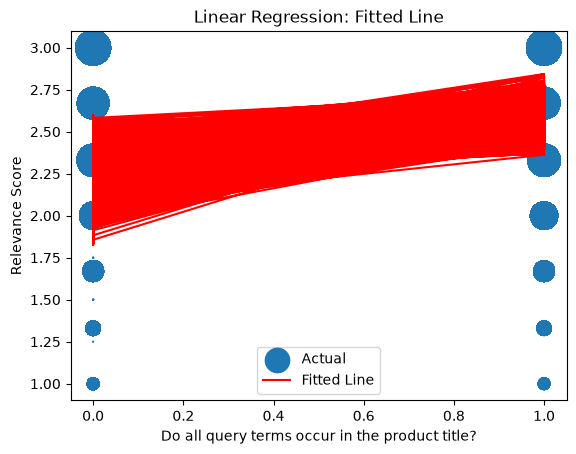

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

weight_counter = Counter(y_test)
weights = [weight_counter[i]/10 for i in y_test]

plt.scatter(test_data['all_words_in_title'], y_test, label='Actual', s=weights)
plt.plot(test_data['all_words_in_title'], y_pred, color='red', label='Fitted Line')
plt.xlabel('Do all query terms occur in the product title?')
plt.ylabel('Relevance Score')
plt.title('Linear Regression: Fitted Line')
plt.legend()
plt.show()